In [33]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold

In [34]:
DATA_PATH = PROJECT_ROOT / "data" / "processed"

feature_df = pd.read_csv(
    DATA_PATH / "feature_dataset.csv"
)

print(feature_df.shape)

feature_df.head()

(90000, 65)


,M20,M21,M22,M40,M41,M42,M43,M60,M61,M62,...,SpectralFlatness,SpectralRollOff,SpectralBandwidth,MphiNL,SigmaDP,SigmaZ2,M2M4SNR,Modulation,OriginalSNR,Label
0,0.000026,0.000069,0.000026,3.157343e-09,2.930586e-09,6.460820e-09,2.930586e-09,3.500275e-13,4.633123e-13,4.327737e-13,...,0.627377,43,18.381460,1.0,3.797474,0.005159,1.105342,QPSK,2,8
1,0.000028,0.000068,0.000028,3.215990e-09,2.804059e-09,6.498267e-09,2.804059e-09,1.781424e-13,4.586850e-13,3.564625e-13,...,0.630078,48,19.898510,1.0,2.716261,0.005688,0.889030,QPSK,2,8
2,0.000004,0.000069,0.000004,2.910366e-09,8.069788e-10,7.002352e-09,8.069788e-10,1.588626e-13,3.876018e-13,1.401655e-13,...,0.624587,49,19.985046,1.0,3.927797,0.005326,0.360494,QPSK,2,8
3,0.000005,0.000070,0.000005,3.598735e-09,7.073600e-10,7.253493e-09,7.073600e-10,3.053956e-13,5.095078e-13,1.243595e-13,...,0.606380,47,19.097059,1.0,2.835475,0.006038,0.163557,QPSK,2,8
4,0.000018,0.000068,0.000018,2.224453e-09,2.107830e-09,6.237477e-09,2.107830e-09,1.804345e-13,2.696272e-13,2.822643e-13,...,0.602295,43,19.311969,1.0,2.253482,0.005549,1.231920,QPSK,2,8


In [35]:
print("="*70)

print(feature_df.info())

print("="*70)

print(feature_df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   M20                    90000 non-null  float64
 1   M21                    90000 non-null  float64
 2   M22                    90000 non-null  float64
 3   M40                    90000 non-null  float64
 4   M41                    90000 non-null  float64
 5   M42                    90000 non-null  float64
 6   M43                    90000 non-null  float64
 7   M60                    90000 non-null  float64
 8   M61                    90000 non-null  float64
 9   M62                    90000 non-null  float64
 10  M63                    90000 non-null  float64
 11  M80                    90000 non-null  float64
 12  M84                    90000 non-null  float64
 13  C20                    90000 non-null  float64
 14  C21                    90000 non-null  float64
 15  C40          

In [36]:
missing = feature_df.isnull().sum()

missing = missing[missing > 0]

print(missing)

print()

print("Total Missing Values :", missing.sum())

M2M4SNR    8905
dtype: int64

Total Missing Values : 8905


In [37]:
numeric = feature_df.select_dtypes(include=np.number)

inf_count = np.isinf(numeric.values).sum()

print("Infinite Values :", inf_count)

Infinite Values : 0


In [38]:
duplicates = feature_df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [39]:
duplicate_columns = feature_df.T.duplicated()

duplicate_columns = feature_df.columns[duplicate_columns]

print(duplicate_columns.tolist())

['M22', 'C20', 'C21', 'C80', 'C84', 'GammaMean', 'GammaMax']


In [40]:
X = feature_df.drop(
    columns=[
        "Modulation",
        "OriginalSNR"
    ]
)

selector = VarianceThreshold()

selector.fit(X)

constant = X.columns[
    ~selector.get_support()
]

print()

print("Constant Features")

print("------------------")

print(list(constant))


Constant Features
------------------
['WaveletASKCorrelation']


In [41]:
corr = X.corr().abs()

upper = corr.where(

    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)

)

high_corr = []

for column in upper.columns:

    for row in upper.index:

        if upper.loc[row, column] > 0.95:

            high_corr.append(

                (

                    row,

                    column,

                    upper.loc[row, column]

                )

            )

print()

print("Highly Correlated Features")

print("----------------------------")

for item in high_corr:

    print(item)


Highly Correlated Features
----------------------------
('M20', 'M22', np.float64(1.0))
('M40', 'M41', np.float64(0.9970119511067099))
('M40', 'M42', np.float64(0.9929541311923022))
('M41', 'M42', np.float64(0.9940661227907158))
('M40', 'M43', np.float64(0.9970119513171729))
('M41', 'M43', np.float64(0.9999999999999822))
('M42', 'M43', np.float64(0.9940661227152763))
('M60', 'M61', np.float64(0.9998487176103922))
('M60', 'M62', np.float64(0.9997215010550421))
('M61', 'M62', np.float64(0.9998814350566998))
('M60', 'M63', np.float64(0.9994293255430017))
('M61', 'M63', np.float64(0.9997582177089184))
('M62', 'M63', np.float64(0.9998304828904871))
('M60', 'M80', np.float64(0.9878066181549215))
('M61', 'M80', np.float64(0.9870690237079571))
('M62', 'M80', np.float64(0.9863346502604733))
('M63', 'M80', np.float64(0.985700060695666))
('M60', 'M84', np.float64(0.9882170905315298))
('M61', 'M84', np.float64(0.9876315553666039))
('M62', 'M84', np.float64(0.9869903122422181))
('M63', 'M84', np.f

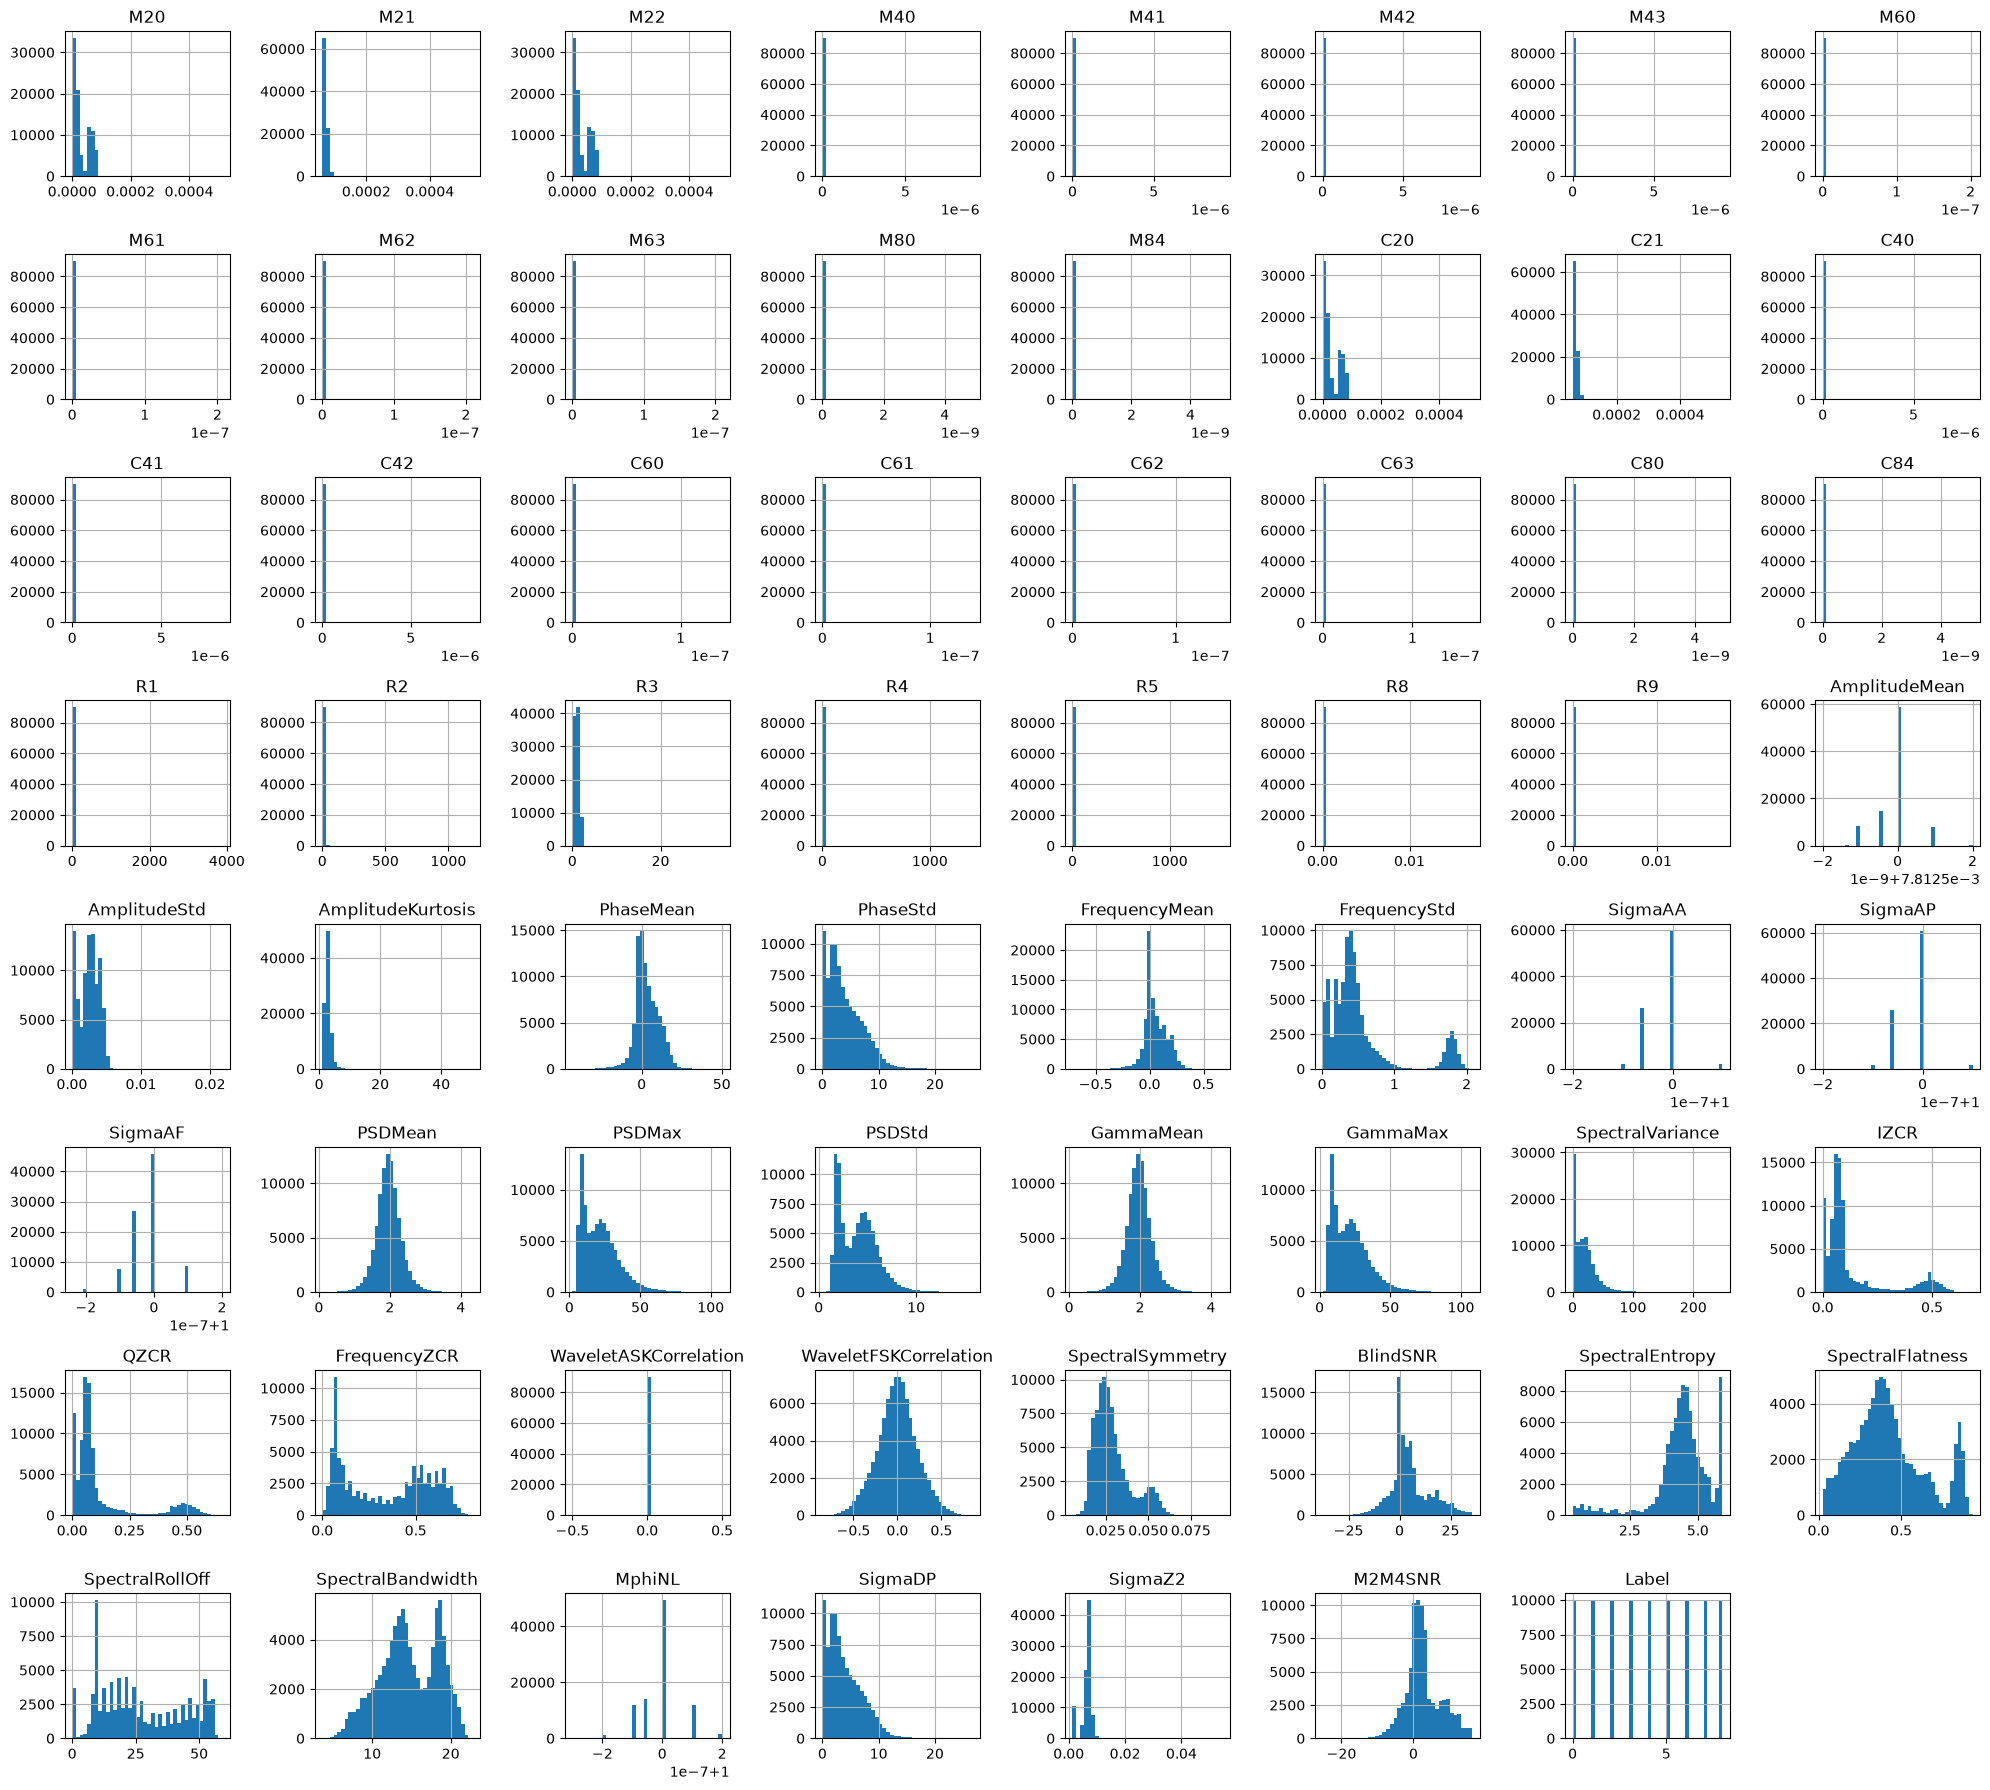

In [42]:
numeric = X.select_dtypes(include=np.number)

numeric.hist(

    figsize=(20,18),

    bins=40

)

plt.tight_layout()

plt.show()

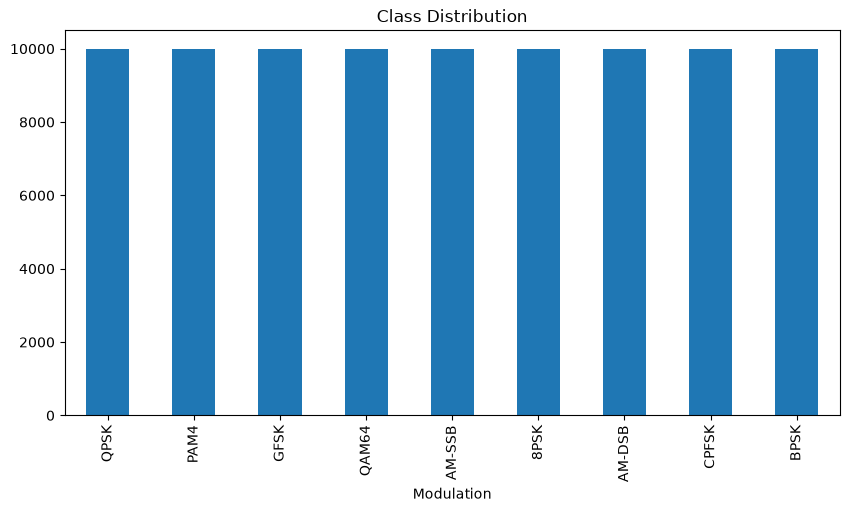

In [43]:
feature_df["Modulation"].value_counts().plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Class Distribution")

plt.show()

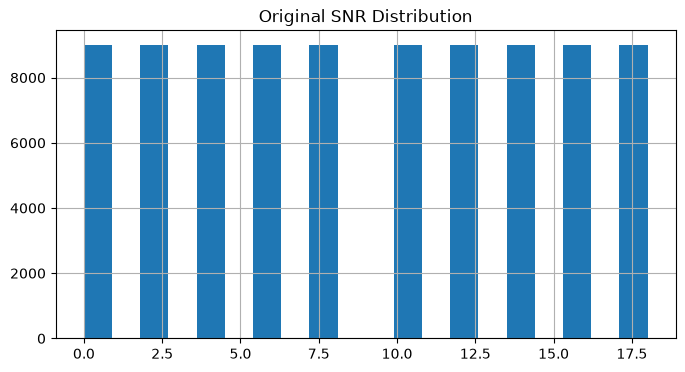

In [44]:
feature_df["OriginalSNR"].hist(

    bins=20,

    figsize=(8,4)

)

plt.title("Original SNR Distribution")

plt.show()

In [45]:
print("="*60)

print("Dataset Shape")

print(feature_df.shape)

print()

print("Feature Count")

print(len(X.columns))

print()

print("Class Count")

print(feature_df["Modulation"].nunique())

print()

print("SNR Levels")

print(feature_df["OriginalSNR"].nunique())

print("="*60)

Dataset Shape
(90000, 65)

Feature Count
63

Class Count
9

SNR Levels
10


In [46]:
REPORT = PROJECT_ROOT / "results" / "reports"

REPORT.mkdir(

    parents=True,

    exist_ok=True

)

with open(

    REPORT / "feature_validation_report.txt",

    "w"

) as file:

    file.write(

        "Feature Validation Report\n"

    )

    file.write(

        "="*60 + "\n"

    )

    file.write(

        f"Dataset Shape : {feature_df.shape}\n"

    )

    file.write(

        f"Feature Count : {len(X.columns)}\n"

    )

    file.write(

        f"Classes : {feature_df['Modulation'].nunique()}\n"

    )

    file.write(

        f"SNR Levels : {feature_df['OriginalSNR'].nunique()}\n"

    )

    file.write(

        f"Duplicate Rows : {duplicates}\n"

    )

    file.write(

        f"Infinite Values : {inf_count}\n"

    )

    file.write(

        f"Missing Values : {missing.sum()}\n"

    )

print("Validation Report Saved.")

Validation Report Saved.
